Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


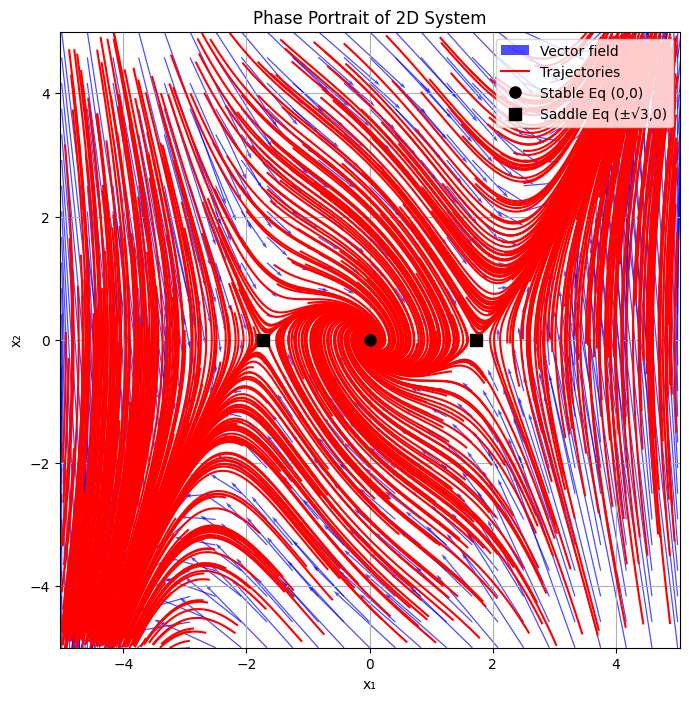

Generated 700 random trajectories
Rejected 0 short trajectories during generation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f1(x1, x2):
    return x2

def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2

x1_range = np.linspace(-5, 5, 25)
x2_range = np.linspace(-5, 5, 25)
x1, x2 = np.meshgrid(x1_range, x2_range)
U = f1(x1, x2)
V = f2(x1, x2)

plt.figure(figsize=(8, 8))
quiv = plt.quiver(
    x1, x2, U, V,
    color='b',
    alpha=0.7,
    angles='xy',
    scale_units='xy',
    scale=5,
    width=0.002          
)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Phase Portrait of 2D System')
plt.axis('equal')
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.grid(True)

num_trajectories = 700
np.random.seed(42)

def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]

lines = []
t_span = [0, 6]
all_trajectories = []
min_length = 7
i = 0 
rejected_count = 0
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 400))
    max_val = max(np.abs(sol.y[0]).max(), np.abs(sol.y[1]).max())
    solution = []
    i = 0
    for point_0 in sol.y[0]:
        point_1 = sol.y[1][i]
        if point_0 < 5 and point_0 > -5 and point_1 < 5 and point_1 > -5:
            solution.append([point_0, point_1])
        i += 1
            
    all_trajectories.append(solution)
    line, = plt.plot([k[0] for k in solution],  [k[1] for k in solution], 'r', linewidth=1.5)
    lines.append(line)


eq1 = plt.plot(0, 0, 'ko', markersize=8)
eq2 = plt.plot(3**0.5, 0, 'ks', markersize=8)
eq3 = plt.plot(-3**0.5, 0, 'ks', markersize=8)
plt.legend(
    [quiv, lines[0], eq1[0], eq2[0]],
    ['Vector field', 'Trajectories', 'Stable Eq (0,0)', 'Saddle Eq (±√3,0)'],
    loc='upper right'
)
plt.show()
print(f"Generated {num_trajectories} random trajectories")
print(f"Rejected {rejected_count} short trajectories during generation.")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f1(x1, x2):
    return x2

def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2

x1_range = np.linspace(-5, 5, 25)
x2_range = np.linspace(-5, 5, 25)
x1, x2 = np.meshgrid(x1_range, x2_range)
U = f1(x1, x2)
V = f2(x1, x2)

plt.figure(figsize=(8, 8))
quiv = plt.quiver(
    x1, x2, U, V,
    color='b',
    alpha=0.7,
    angles='xy',
    scale_units='xy',
    scale=5,
    width=0.002          
)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Phase Portrait of 2D System')
plt.axis('equal')
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.grid(True)

num_trajectories = 700
np.random.seed(42)

def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]

lines = []
t_span = [0, 6]
all_trajectories = []
min_length = 7
i = 0 
rejected_count = 0
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 400))
    max_val = max(np.abs(sol.y[0]).max(), np.abs(sol.y[1]).max())
    solution = []
    i = 0
    for point_0 in sol.y[0]:
        point_1 = sol.y[1][i]
        if point_0 < 5 and point_0 > -5 and point_1 < 5 and point_1 > -5:
            solution.append([point_0, point_1])
        i += 1
            
    all_trajectories.append(solution)
    line, = plt.plot([k[0] for k in solution],  [k[1] for k in solution], 'r', linewidth=1.5)
    lines.append(line)


eq1 = plt.plot(0, 0, 'ko', markersize=8)
eq2 = plt.plot(3**0.5, 0, 'ks', markersize=8)
eq3 = plt.plot(-3**0.5, 0, 'ks', markersize=8)
plt.legend(
    [quiv, lines[0], eq1[0], eq2[0]],
    ['Vector field', 'Trajectories', 'Stable Eq (0,0)', 'Saddle Eq (±√3,0)'],
    loc='upper right'
)
plt.show()
print(f"Generated {num_trajectories} random trajectories")
print(f"Rejected {rejected_count} short trajectories during generation.")


import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim

block_size = 10
n_embd = 20
num_heads = 1
head_size = n_embd // num_heads
dropout_rate = 0.2

# Prep Data
inputs = []
for trajectory in all_trajectories:
    for i in range(len(trajectory) - block_size):
        inputs.append(trajectory[i:i + block_size + 1])
training_inputs = inputs[:int(len(inputs)*.75)]
test_inputs = inputs[int(len(inputs)*.75):]


# Train Model
embed = nn.Linear(2, n_embd)
w_key = nn.Linear(n_embd, head_size, bias=False)
w_query = nn.Linear(n_embd, head_size, bias=False)
w_value = nn.Linear(n_embd, head_size, bias=False)
w_attn_output = nn.Linear(head_size * num_heads, n_embd)
dropout = nn.Dropout(dropout_rate)
norm_attn_gain = nn.Parameter(torch.ones(n_embd))
norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
w_ffn = nn.Linear(n_embd, 4 * n_embd)
w_ffn_output = nn.Linear(4 * n_embd, n_embd)
norm_logits_gain = nn.Parameter(torch.ones(n_embd))
norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
w_logits_output = nn.Linear(n_embd, 2)

params = [
    embed.weight, w_key.weight, w_query.weight, w_value.weight, w_attn_output.weight,
    norm_attn_gain, norm_attn_bias,
    w_ffn.weight, w_ffn.bias, w_ffn_output.weight, w_ffn_output.bias,
    norm_logits_gain, norm_logits_bias,
    w_logits_output.weight, w_logits_output.bias
]
optimizer = optim.Adam(params, lr=0.001)

# Training
n_epochs = 7
for epoch in range(n_epochs):
    epoch_loss = 0
    for input in training_inputs:
        input_sequence = torch.tensor(input, dtype=torch.float32)
        input_data = input_sequence[:block_size]
        target = input_sequence[-1]
        # Attention Heads
        embedded_input = embed(input_data)
        K, Q, V = w_key(embedded_input), w_query(embedded_input), w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(head_size))
        #masked_attention_scores = raw_attention_scores.masked_fill(torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf'))
        attention_probabilities = dropout(F.softmax(raw_attention_scores, dim=-1))
        attention_output = dropout(w_attn_output(attention_probabilities @ V))
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + norm_attn_bias
        # FFN
        FFN_activations = F.relu(w_ffn(FFN_in_normalized))
        FFN_output = dropout(w_ffn_output(FFN_activations))
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + norm_logits_bias
        # Linear
        logits = w_logits_output(logits_normalized)

        # Backpropagation
        prediction = logits[-1]
        loss = F.mse_loss(prediction, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch}, Loss: {epoch_loss / len(training_inputs):.6f}")
total_params = 0
for i, p in enumerate(params):
    n = p.numel()
    total_params += n
    print(f"Param {i}: {n} parameters, shape: {p.shape}")
print(f"\nTotal parameters: {total_params}")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import math

# Set models to evaluation mode
embed.eval()
dropout.eval()

# Initialize chain storage
chains = []

with torch.no_grad():
    j = 0
    for idx, test_input in enumerate(test_inputs):
        # Initialize chain with the first block_size elements
        chain = test_input[:block_size]
        chains.append(chain)
        
        # Generate 80 prediction steps
        i = 0
        while i < 80:
            # Prepare input sequence
            test_input_sequence = torch.tensor(chain, dtype=torch.float32)
            test_input_data = test_input_sequence[-block_size:]
            test_target = test_input_sequence[-1]
            
            # Embedding layer
            test_embedded_input = embed(test_input_data)
            
            # Attention mechanism
            K = w_key(test_embedded_input)
            Q = w_query(test_embedded_input)
            V = w_value(test_embedded_input)
            
            # Calculate attention scores
            raw_attention_scores = (Q @ K.transpose(-2, -1)) * (1.0 / math.sqrt(head_size))
            
            # Optional: Masked attention (currently commented out)
            # masked_attention_scores = raw_attention_scores.masked_fill(
            #     torch.tril(torch.ones(block_size, block_size)) == 0, 
            #     float('-inf')
            # )
            
            # Attention probabilities and output
            attention_probabilities = F.softmax(raw_attention_scores, dim=-1)
            attention_output = w_attn_output(attention_probabilities @ V)
            
            # Feed-forward network with residual connection and normalization
            FFN_in_raw = attention_output + test_embedded_input
            FFN_in_normalized = (
                norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) 
                + norm_attn_bias
            )
            
            # FFN layers
            FFN_activations = F.relu(w_ffn(FFN_in_normalized))
            FFN_output = w_ffn_output(FFN_activations)
            
            # Output normalization
            logits_raw = FFN_output + FFN_in_normalized
            logits_normalized = (
                norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) 
                + norm_logits_bias
            )
            
            # Final prediction
            logits = w_logits_output(logits_normalized)
            prediction = logits[-1].tolist()
            
            # Update chain with prediction
            chain = chain[1:]
            chain.append(prediction)
            chains[j].append(prediction)
            
            i += 1
        j += 1

# Visualization
fig, ax1 = plt.subplots(1, figsize=(12, 10))

for chain in chains:
    chain_array = np.array(chain)
    x = chain_array[:, 0]
    y = chain_array[:, 1]
    
    # Plot initial part (ground truth) in blue
    ax1.plot(x[:block_size], y[:block_size], 
             color='blue', alpha=0.8, linewidth=1.5, label='Initial' if chain == chains[0] else '')
    
    # Plot predicted part in red
    ax1.plot(x[block_size-1:], y[block_size-1:], 
             color='red', alpha=0.8, linewidth=1.5, label='Predicted' if chain == chains[0] else '')

# Add reference lines
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.axvline(0, color='k', linestyle='--', linewidth=0.8)

# Labels and styling
ax1.set_title(f"Neural Network Generated Trajectories ({len(chains)} Trajectories)", fontsize=14)
ax1.set_xlabel("X", fontsize=12)
ax1.set_ylabel("Y", fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_xlim(-5, 7.5)
ax1.set_ylim(-5, 7.5)
ax1.legend()

plt.tight_layout()
plt.show()

Epoch 0, Loss: 0.007549
Epoch 1, Loss: 0.000790
Epoch 2, Loss: 0.000769
Epoch 3, Loss: 0.000789
Epoch 4, Loss: 0.000700
Epoch 5, Loss: 0.000741
Epoch 6, Loss: 0.000728
Param 0: 40 parameters, shape: torch.Size([20, 2])
Param 1: 400 parameters, shape: torch.Size([20, 20])
Param 2: 400 parameters, shape: torch.Size([20, 20])
Param 3: 400 parameters, shape: torch.Size([20, 20])
Param 4: 400 parameters, shape: torch.Size([20, 20])
Param 5: 20 parameters, shape: torch.Size([20])
Param 6: 20 parameters, shape: torch.Size([20])
Param 7: 1600 parameters, shape: torch.Size([80, 20])
Param 8: 80 parameters, shape: torch.Size([80])
Param 9: 1600 parameters, shape: torch.Size([20, 80])
Param 10: 20 parameters, shape: torch.Size([20])
Param 11: 20 parameters, shape: torch.Size([20])
Param 12: 20 parameters, shape: torch.Size([20])
Param 13: 40 parameters, shape: torch.Size([2, 20])
Param 14: 2 parameters, shape: torch.Size([2])

Total parameters: 5062


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_72647/2665779165.py:109: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/noahschwartz/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


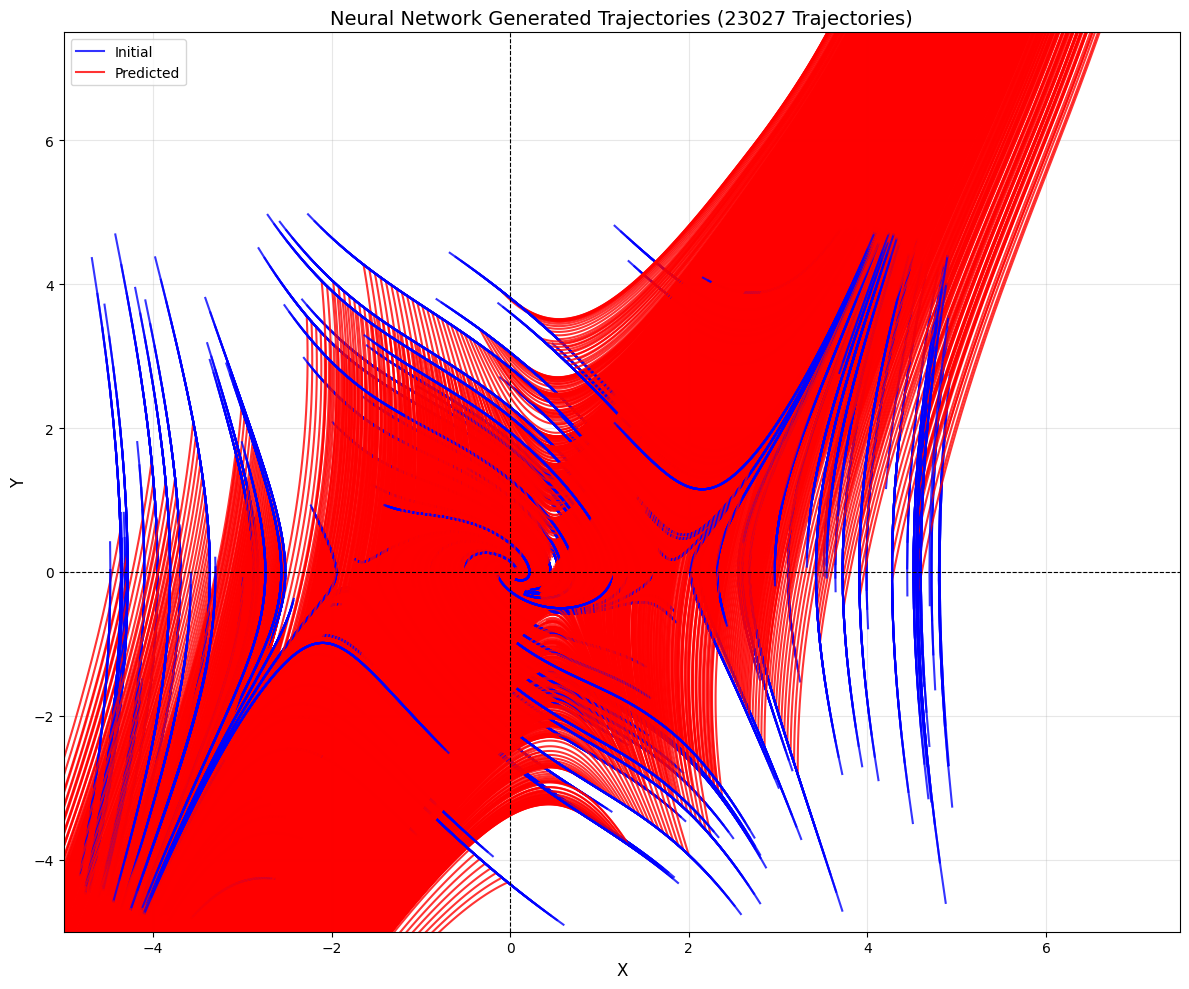

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import math

# Set models to evaluation mode
embed.eval()
dropout.eval()

# Initialize chain storage
chains = []

with torch.no_grad():
    j = 0
    for idx, test_input in enumerate(test_inputs):
        # Initialize chain with the first block_size elements
        chain = test_input[:block_size]
        chains.append(chain)
        
        # Generate 80 prediction steps
        i = 0
        while i < 80:
            # Prepare input sequence
            test_input_sequence = torch.tensor(chain, dtype=torch.float32)
            test_input_data = test_input_sequence[-block_size:]
            test_target = test_input_sequence[-1]
            
            # Embedding layer
            test_embedded_input = embed(test_input_data)
            
            # Attention mechanism
            K = w_key(test_embedded_input)
            Q = w_query(test_embedded_input)
            V = w_value(test_embedded_input)
            
            # Calculate attention scores
            raw_attention_scores = (Q @ K.transpose(-2, -1)) * (1.0 / math.sqrt(head_size))
            
            # Optional: Masked attention (currently commented out)
            # masked_attention_scores = raw_attention_scores.masked_fill(
            #     torch.tril(torch.ones(block_size, block_size)) == 0, 
            #     float('-inf')
            # )
            
            # Attention probabilities and output
            attention_probabilities = F.softmax(raw_attention_scores, dim=-1)
            attention_output = w_attn_output(attention_probabilities @ V)
            
            # Feed-forward network with residual connection and normalization
            FFN_in_raw = attention_output + test_embedded_input
            FFN_in_normalized = (
                norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) 
                + norm_attn_bias
            )
            
            # FFN layers
            FFN_activations = F.relu(w_ffn(FFN_in_normalized))
            FFN_output = w_ffn_output(FFN_activations)
            
            # Output normalization
            logits_raw = FFN_output + FFN_in_normalized
            logits_normalized = (
                norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) 
                + norm_logits_bias
            )
            
            # Final prediction
            logits = w_logits_output(logits_normalized)
            prediction = logits[-1].tolist()
            
            # Update chain with prediction
            chain = chain[1:]
            chain.append(prediction)
            chains[j].append(prediction)
            
            i += 1
        j += 1

# Visualization
fig, ax1 = plt.subplots(1, figsize=(12, 10))

for chain in chains:
    chain_array = np.array(chain)
    x = chain_array[:, 0]
    y = chain_array[:, 1]
    
    # Plot initial part (ground truth) in blue
    ax1.plot(x[:block_size], y[:block_size], 
             color='blue', alpha=0.8, linewidth=1.5, label='Initial' if chain == chains[0] else '')
    
    # Plot predicted part in red
    ax1.plot(x[block_size-1:], y[block_size-1:], 
             color='red', alpha=0.8, linewidth=1.5, label='Predicted' if chain == chains[0] else '')

# Add reference lines
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.axvline(0, color='k', linestyle='--', linewidth=0.8)

# Labels and styling
ax1.set_title(f"Neural Network Generated Trajectories ({len(chains)} Trajectories)", fontsize=14)
ax1.set_xlabel("X", fontsize=12)
ax1.set_ylabel("Y", fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_xlim(-5, 7.5)
ax1.set_ylim(-5, 7.5)
ax1.legend()

plt.tight_layout()
plt.show()

In [6]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout_rate):
        super().__init__()
        self.head_size = head_size
        self.w_key = nn.Linear(n_embd, head_size, bias=False)
        self.w_query = nn.Linear(n_embd, head_size, bias=False)
        self.w_value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        K = self.w_key(embedded_input)
        Q = self.w_query(embedded_input)
        V = self.w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(self.head_size))
        masked_attention_scores = raw_attention_scores.masked_fill(
            torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf')
        )
        attention_probabilities = self.dropout(F.softmax(masked_attention_scores, dim=-1))
        return attention_probabilities @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([
            AttentionHead(n_embd, head_size, dropout_rate) for _ in range(num_heads)
        ])
        self.w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        head_outputs = [head(embedded_input, block_size) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        return self.dropout(self.w_attn_output(concatenated))
    
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout_rate):
        super().__init__()
        self.w_ffn = nn.Linear(n_embd, 4 * n_embd)
        self.w_ffn_output = nn.Linear(4 * n_embd, n_embd)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        FFN_activations = F.relu(self.w_ffn(x))
        return self.dropout(self.w_ffn_output(FFN_activations))
    
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.attention = MultiHeadAttention(n_embd, num_heads, head_size, dropout_rate)
        self.norm_attn_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
        self.ffn = FeedForward(n_embd, dropout_rate)
        self.norm_logits_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
    
    def forward(self, embedded_input, block_size):
        # Attention
        attention_output = self.attention(embedded_input, block_size)
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = self.norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + self.norm_attn_bias
        # FFN
        FFN_output = self.ffn(FFN_in_normalized)
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = self.norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + self.norm_logits_bias
        return logits_normalized


class TransformerModel(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(2, n_embd, bias=False)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, num_heads, head_size, dropout_rate) for _ in range(num_layers)
        ])
        self.w_logits_output = nn.Linear(n_embd, 2)
    
    def forward(self, input_data, block_size):
        embedded_input = self.embed(input_data)
        x = embedded_input
        for block in self.blocks:
            x = block(x, block_size)
        # Linear
        logits = self.w_logits_output(x)
        return logits



# Train Model
block_size = 16
n_embd = 128
num_heads = 4 # must be factor of 10 (block size)
batch_size = 64
head_size = n_embd // num_heads
dropout_rate = 0.1
num_layers = 3
n_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def f1(x1, x2):
    return x2
def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2
def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]
print("Generating trajectories...")
num_trajectories = 800
t_span = [0, 6]
all_trajectories = []
np.random.seed(42)
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 100))
    traj = np.vstack(sol.y).T
    if np.abs(traj).max() < 6:
        all_trajectories.append(traj)
print(f"Generated {len(all_trajectories)} valid trajectories.")
all_data = np.vstack(all_trajectories)
mean = np.mean(all_data, axis=0)
std = np.std(all_data, axis=0)
def normalize(data):
    return (data - mean) / (std + 1e-6)
def denormalize(data):
    return data * (std + 1e-6) + mean
X_list = []
Y_list = []
for traj in all_trajectories:
    traj_norm = normalize(traj)
    for i in range(len(traj_norm) - block_size):
        seq = traj_norm[i:i+block_size]
        target_next_point = traj_norm[i+block_size]
        current_last_point = traj_norm[i+block_size-1]
        target_delta = target_next_point - current_last_point
        X_list.append(seq)
        Y_list.append(target_delta)
X_data = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_data = torch.tensor(np.array(Y_list), dtype=torch.float32)
dataset = TensorDataset(X_data, Y_data)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)




model = TransformerModel(n_embd, num_heads, head_size, dropout_rate, num_layers)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
print("Starting training...")
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        optimizer.zero_grad()
        # Predict delta
        pred_delta = model(X_batch, block_size)[:, -1, :]
        
        loss = criterion(pred_delta, Y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.6f}")

Generating trajectories...
Generated 800 valid trajectories.
Starting training...
Epoch 1/10 | Loss: 0.002271
Epoch 2/10 | Loss: 0.000036
Epoch 3/10 | Loss: 0.000024
Epoch 4/10 | Loss: 0.000021
Epoch 5/10 | Loss: 0.000016
Epoch 6/10 | Loss: 0.000013
Epoch 7/10 | Loss: 0.000010
Epoch 8/10 | Loss: 0.000013
Epoch 9/10 | Loss: 0.000008
Epoch 10/10 | Loss: 0.000010


Generating inference plots...


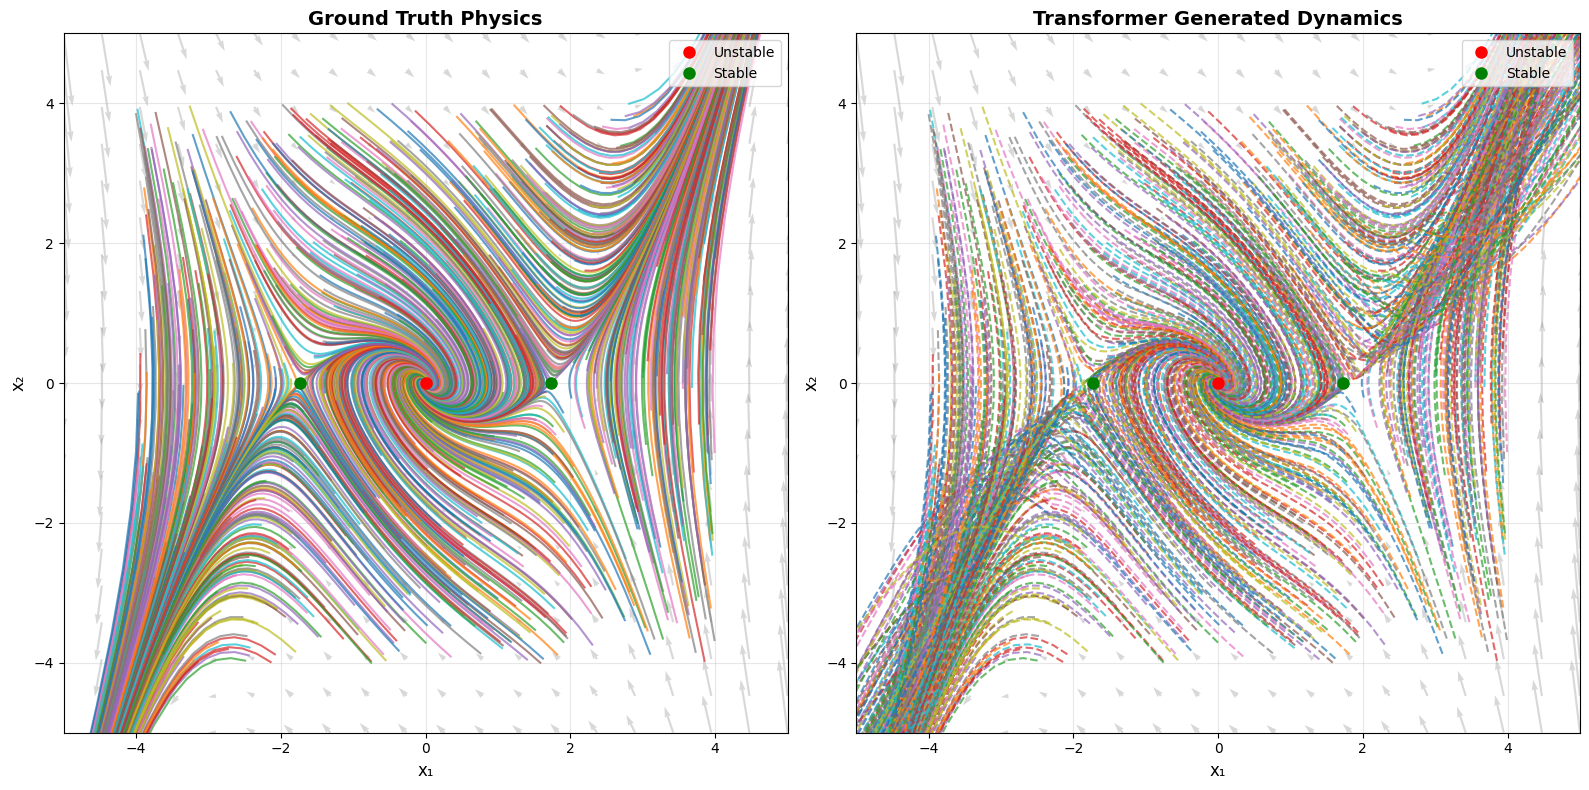

Visualization complete!


In [9]:
# ==========================================
# INFERENCE & VISUALIZATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

model.eval()
print("Generating inference plots...")

# Setup plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 1. Ground Truth Phase Portrait (Vector Field)
x1_range = np.linspace(-5, 5, 20)
x2_range = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1_range, x2_range)
U = f1(X1, X2)
V = f2(X1, X2)
ax1.quiver(X1, X2, U, V, color='gray', alpha=0.3)
ax2.quiver(X1, X2, U, V, color='gray', alpha=0.3)

# 2. Generate Autoregressive Trajectories
np.random.seed(123)  # Different seed for test trajectories
num_test_traj = 1000
start_points = np.random.uniform(-4, 4, size=(num_test_traj, 2))

for idx, start in enumerate(start_points):
    # --- A. Get True Trajectory ---
    sol = solve_ivp(system, [0, 10], start, t_eval=np.linspace(0, 10, 200))
    true_traj = sol.y.T
    
    ax1.plot(true_traj[:, 0], true_traj[:, 1], linewidth=1.5, alpha=0.7)
    
    # --- B. Neural Network Prediction ---
    # Initialize with first 'block_size' points from truth to prime the model
    initial_seq = normalize(true_traj[:block_size])
    current_seq = torch.tensor(initial_seq, dtype=torch.float32).unsqueeze(0).to(device)
    
    pred_traj = list(initial_seq)
    
    with torch.no_grad():
        for _ in range(200 - block_size):
            # Predict delta
            delta_pred = model(current_seq, block_size)[:, -1, :]  # Shape (1, 2)
            
            # Calculate next point: last_point + delta
            last_point = current_seq[:, -1, :]
            next_point = last_point + delta_pred
            
            # Update sequence: slide window
            next_point_unsqueezed = next_point.unsqueeze(1)
            current_seq = torch.cat((current_seq[:, 1:, :], next_point_unsqueezed), dim=1)
            
            pred_traj.append(next_point.cpu().numpy()[0])
    
    # Denormalize for plotting
    pred_traj_np = denormalize(np.array(pred_traj))
    
    # Plot
    ax2.plot(pred_traj_np[:, 0], pred_traj_np[:, 1], linewidth=1.5, alpha=0.7, linestyle='--')

# Styling
ax1.set_title("Ground Truth Physics", fontsize=14, fontweight='bold')
ax2.set_title("Transformer Generated Dynamics", fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.grid(True, alpha=0.3)
    # Mark equilibrium points
    ax.plot(0, 0, 'ro', markersize=8, label='Unstable')
    ax.plot(np.sqrt(3), 0, 'go', markersize=8, label='Stable')
    ax.plot(-np.sqrt(3), 0, 'go', markersize=8)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Visualization complete!")

In [11]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout_rate):
        super().__init__()
        self.head_size = head_size
        self.w_key = nn.Linear(n_embd, head_size, bias=False)
        self.w_query = nn.Linear(n_embd, head_size, bias=False)
        self.w_value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        K = self.w_key(embedded_input)
        Q = self.w_query(embedded_input)
        V = self.w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(self.head_size))
        masked_attention_scores = raw_attention_scores.masked_fill(
            torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf')
        )
        attention_probabilities = self.dropout(F.softmax(masked_attention_scores, dim=-1))
        return attention_probabilities @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([
            AttentionHead(n_embd, head_size, dropout_rate) for _ in range(num_heads)
        ])
        self.w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        head_outputs = [head(embedded_input, block_size) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        return self.dropout(self.w_attn_output(concatenated))
    
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout_rate):
        super().__init__()
        self.w_ffn = nn.Linear(n_embd, 4 * n_embd)
        self.w_ffn_output = nn.Linear(4 * n_embd, n_embd)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        FFN_activations = F.relu(self.w_ffn(x))
        return self.dropout(self.w_ffn_output(FFN_activations))
    
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.attention = MultiHeadAttention(n_embd, num_heads, head_size, dropout_rate)
        self.norm_attn_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
        self.ffn = FeedForward(n_embd, dropout_rate)
        self.norm_logits_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
    
    def forward(self, embedded_input, block_size):
        # Attention
        attention_output = self.attention(embedded_input, block_size)
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = self.norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + self.norm_attn_bias
        # FFN
        FFN_output = self.ffn(FFN_in_normalized)
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = self.norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + self.norm_logits_bias
        return logits_normalized


class TransformerModel(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(2, n_embd, bias=False)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, num_heads, head_size, dropout_rate) for _ in range(num_layers)
        ])
        self.w_logits_output = nn.Linear(n_embd, 2)
    
    def forward(self, input_data, block_size):
        embedded_input = self.embed(input_data)
        x = embedded_input
        for block in self.blocks:
            x = block(x, block_size)
        # Linear
        logits = self.w_logits_output(x)
        return logits



# Train Model
block_size = 16
n_embd = 128
num_heads = 4 # must be factor of 10 (block size)
batch_size = 64
head_size = n_embd // num_heads
dropout_rate = 0.1
num_layers = 3
n_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def f1(x1, x2):
    return x2
def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2
def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]
print("Generating trajectories...")
num_trajectories = 800
t_span = [0, 6]
all_trajectories = []
np.random.seed(42)
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 100))
    traj = np.vstack(sol.y).T
    if np.abs(traj).max() < 6:
        all_trajectories.append(traj)
print(f"Generated {len(all_trajectories)} valid trajectories.")
all_data = np.vstack(all_trajectories)
mean = np.mean(all_data, axis=0)
std = np.std(all_data, axis=0)
def normalize(data):
    return data
def denormalize(data):
    return data
X_list = []
Y_list = []
for traj in all_trajectories:
    traj_norm = normalize(traj)
    for i in range(len(traj_norm) - block_size):
        seq = traj_norm[i:i+block_size]
        target_next_point = traj_norm[i+block_size]
        current_last_point = traj_norm[i+block_size-1]
        target_delta = target_next_point - current_last_point
        X_list.append(seq)
        Y_list.append(target_delta)
X_data = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_data = torch.tensor(np.array(Y_list), dtype=torch.float32)
dataset = TensorDataset(X_data, Y_data)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)




model = TransformerModel(n_embd, num_heads, head_size, dropout_rate, num_layers)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
print("Starting training...")
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        optimizer.zero_grad()
        # Predict delta
        pred_delta = model(X_batch, block_size)[:, -1, :]
        
        loss = criterion(pred_delta, Y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.6f}")

Generating trajectories...
Generated 800 valid trajectories.
Starting training...
Epoch 1/10 | Loss: 0.002571
Epoch 2/10 | Loss: 0.000018
Epoch 3/10 | Loss: 0.000015
Epoch 4/10 | Loss: 0.000011
Epoch 5/10 | Loss: 0.000014
Epoch 6/10 | Loss: 0.000009
Epoch 7/10 | Loss: 0.000012
Epoch 8/10 | Loss: 0.000010
Epoch 9/10 | Loss: 0.000006
Epoch 10/10 | Loss: 0.000003


Generating inference plots...


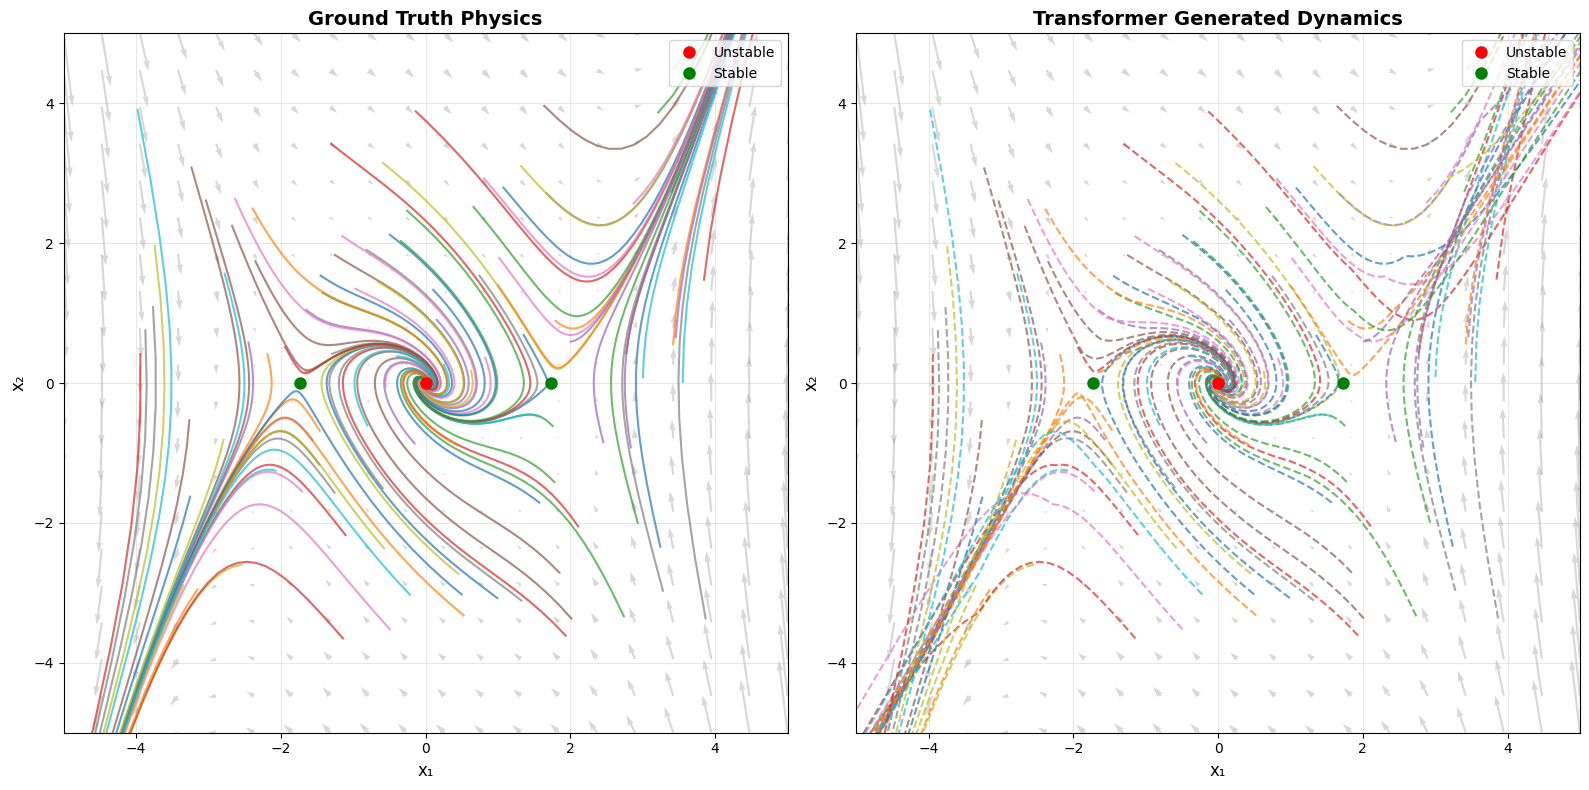

Visualization complete!


In [13]:
# ==========================================
# INFERENCE & VISUALIZATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

model.eval()
print("Generating inference plots...")

# Setup plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 1. Ground Truth Phase Portrait (Vector Field)
x1_range = np.linspace(-5, 5, 20)
x2_range = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1_range, x2_range)
U = f1(X1, X2)
V = f2(X1, X2)
ax1.quiver(X1, X2, U, V, color='gray', alpha=0.3)
ax2.quiver(X1, X2, U, V, color='gray', alpha=0.3)

# 2. Generate Autoregressive Trajectories
np.random.seed(123)  # Different seed for test trajectories
num_test_traj = 100
start_points = np.random.uniform(-4, 4, size=(num_test_traj, 2))

for idx, start in enumerate(start_points):
    # --- A. Get True Trajectory ---
    sol = solve_ivp(system, [0, 10], start, t_eval=np.linspace(0, 10, 200))
    true_traj = sol.y.T
    
    ax1.plot(true_traj[:, 0], true_traj[:, 1], linewidth=1.5, alpha=0.7)
    
    # --- B. Neural Network Prediction ---
    # Initialize with first 'block_size' points from truth to prime the model
    initial_seq = normalize(true_traj[:block_size])
    current_seq = torch.tensor(initial_seq, dtype=torch.float32).unsqueeze(0).to(device)
    
    pred_traj = list(initial_seq)
    
    with torch.no_grad():
        for _ in range(200 - block_size):
            # Predict delta
            delta_pred = model(current_seq, block_size)[:, -1, :]  # Shape (1, 2)
            
            # Calculate next point: last_point + delta
            last_point = current_seq[:, -1, :]
            next_point = last_point + delta_pred
            
            # Update sequence: slide window
            next_point_unsqueezed = next_point.unsqueeze(1)
            current_seq = torch.cat((current_seq[:, 1:, :], next_point_unsqueezed), dim=1)
            
            pred_traj.append(next_point.cpu().numpy()[0])
    
    # Denormalize for plotting
    pred_traj_np = denormalize(np.array(pred_traj))
    
    # Plot
    ax2.plot(pred_traj_np[:, 0], pred_traj_np[:, 1], linewidth=1.5, alpha=0.7, linestyle='--')

# Styling
ax1.set_title("Ground Truth Physics", fontsize=14, fontweight='bold')
ax2.set_title("Transformer Generated Dynamics", fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.grid(True, alpha=0.3)
    # Mark equilibrium points
    ax.plot(0, 0, 'ro', markersize=8, label='Unstable')
    ax.plot(np.sqrt(3), 0, 'go', markersize=8, label='Stable')
    ax.plot(-np.sqrt(3), 0, 'go', markersize=8)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Visualization complete!")

In [14]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout_rate):
        super().__init__()
        self.head_size = head_size
        self.w_key = nn.Linear(n_embd, head_size, bias=False)
        self.w_query = nn.Linear(n_embd, head_size, bias=False)
        self.w_value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        K = self.w_key(embedded_input)
        Q = self.w_query(embedded_input)
        V = self.w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(self.head_size))
        masked_attention_scores = raw_attention_scores.masked_fill(
            torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf')
        )
        attention_probabilities = self.dropout(F.softmax(masked_attention_scores, dim=-1))
        return attention_probabilities @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([
            AttentionHead(n_embd, head_size, dropout_rate) for _ in range(num_heads)
        ])
        self.w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        head_outputs = [head(embedded_input, block_size) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        return self.dropout(self.w_attn_output(concatenated))
    
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout_rate):
        super().__init__()
        self.w_ffn = nn.Linear(n_embd, 4 * n_embd)
        self.w_ffn_output = nn.Linear(4 * n_embd, n_embd)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        FFN_activations = F.relu(self.w_ffn(x))
        return self.dropout(self.w_ffn_output(FFN_activations))
    
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.attention = MultiHeadAttention(n_embd, num_heads, head_size, dropout_rate)
        self.norm_attn_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
        self.ffn = FeedForward(n_embd, dropout_rate)
        self.norm_logits_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
    
    def forward(self, embedded_input, block_size):
        # Attention
        attention_output = self.attention(embedded_input, block_size)
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = self.norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + self.norm_attn_bias
        # FFN
        FFN_output = self.ffn(FFN_in_normalized)
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = self.norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + self.norm_logits_bias
        return logits_normalized


class TransformerModel(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(2, n_embd, bias=False)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, num_heads, head_size, dropout_rate) for _ in range(num_layers)
        ])
        self.w_logits_output = nn.Linear(n_embd, 2)
    
    def forward(self, input_data, block_size):
        embedded_input = self.embed(input_data)
        x = embedded_input
        for block in self.blocks:
            x = block(x, block_size)
        # Linear
        logits = self.w_logits_output(x)
        return logits



# Train Model
block_size = 16
n_embd = 128
num_heads = 4 # must be factor of 10 (block size)
batch_size = 64
head_size = n_embd // num_heads
dropout_rate = 0.1
num_layers = 3
n_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def f1(x1, x2):
    return x2
def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2
def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]
print("Generating trajectories...")
num_trajectories = 800
t_span = [0, 6]
all_trajectories = []
np.random.seed(42)
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 100))
    traj = np.vstack(sol.y).T
    if np.abs(traj).max() < 6:
        all_trajectories.append(traj)
print(f"Generated {len(all_trajectories)} valid trajectories.")
all_data = np.vstack(all_trajectories)
mean = np.mean(all_data, axis=0)
std = np.std(all_data, axis=0)
def normalize(data):
    return data
def denormalize(data):
    return data
X_list = []
Y_list = []
for traj in all_trajectories:
    traj_norm = normalize(traj)
    for i in range(len(traj_norm) - block_size):
        seq = traj_norm[i:i+block_size]
        target_next_point = traj_norm[i+block_size]
        current_last_point = traj_norm[i+block_size-1]
        target_delta = target_next_point
        X_list.append(seq)
        Y_list.append(target_delta)
X_data = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_data = torch.tensor(np.array(Y_list), dtype=torch.float32)
dataset = TensorDataset(X_data, Y_data)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)




model = TransformerModel(n_embd, num_heads, head_size, dropout_rate, num_layers)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
print("Starting training...")
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        optimizer.zero_grad()
        # Predict delta
        pred_delta = model(X_batch, block_size)[:, -1, :]
        
        loss = criterion(pred_delta, Y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.6f}")

Generating trajectories...
Generated 800 valid trajectories.
Starting training...
Epoch 1/10 | Loss: 0.002015
Epoch 2/10 | Loss: 0.000098
Epoch 3/10 | Loss: 0.000068
Epoch 4/10 | Loss: 0.000054
Epoch 5/10 | Loss: 0.000065
Epoch 6/10 | Loss: 0.000035
Epoch 7/10 | Loss: 0.000051
Epoch 8/10 | Loss: 0.000030
Epoch 9/10 | Loss: 0.000015
Epoch 10/10 | Loss: 0.000051


Generating inference plots...


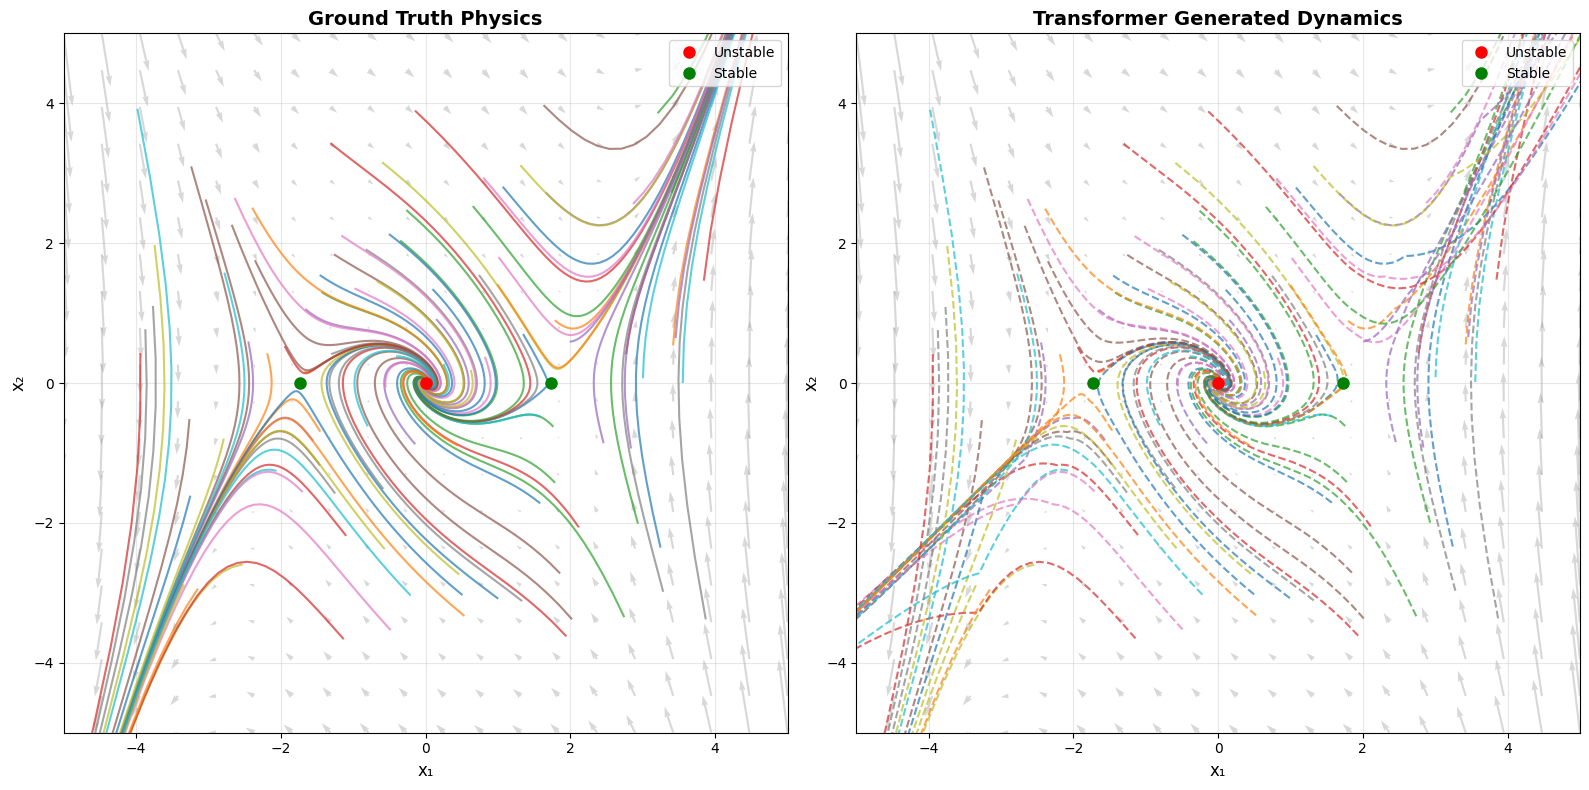

Visualization complete!


In [15]:
# ==========================================
# INFERENCE & VISUALIZATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

model.eval()
print("Generating inference plots...")

# Setup plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 1. Ground Truth Phase Portrait (Vector Field)
x1_range = np.linspace(-5, 5, 20)
x2_range = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1_range, x2_range)
U = f1(X1, X2)
V = f2(X1, X2)
ax1.quiver(X1, X2, U, V, color='gray', alpha=0.3)
ax2.quiver(X1, X2, U, V, color='gray', alpha=0.3)

# 2. Generate Autoregressive Trajectories
np.random.seed(123)  # Different seed for test trajectories
num_test_traj = 100
start_points = np.random.uniform(-4, 4, size=(num_test_traj, 2))

for idx, start in enumerate(start_points):
    # --- A. Get True Trajectory ---
    sol = solve_ivp(system, [0, 10], start, t_eval=np.linspace(0, 10, 200))
    true_traj = sol.y.T
    
    ax1.plot(true_traj[:, 0], true_traj[:, 1], linewidth=1.5, alpha=0.7)
    
    # --- B. Neural Network Prediction ---
    # Initialize with first 'block_size' points from truth to prime the model
    initial_seq = normalize(true_traj[:block_size])
    current_seq = torch.tensor(initial_seq, dtype=torch.float32).unsqueeze(0).to(device)
    
    pred_traj = list(initial_seq)
    
    with torch.no_grad():
        for _ in range(200 - block_size):
            # Predict delta
            delta_pred = model(current_seq, block_size)[:, -1, :]  # Shape (1, 2)
            
            # Calculate next point: last_point + delta
            last_point = current_seq[:, -1, :]
            next_point = delta_pred
            
            # Update sequence: slide window
            next_point_unsqueezed = next_point.unsqueeze(1)
            current_seq = torch.cat((current_seq[:, 1:, :], next_point_unsqueezed), dim=1)
            
            pred_traj.append(next_point.cpu().numpy()[0])
    
    # Denormalize for plotting
    pred_traj_np = denormalize(np.array(pred_traj))
    
    # Plot
    ax2.plot(pred_traj_np[:, 0], pred_traj_np[:, 1], linewidth=1.5, alpha=0.7, linestyle='--')

# Styling
ax1.set_title("Ground Truth Physics", fontsize=14, fontweight='bold')
ax2.set_title("Transformer Generated Dynamics", fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.grid(True, alpha=0.3)
    # Mark equilibrium points
    ax.plot(0, 0, 'ro', markersize=8, label='Unstable')
    ax.plot(np.sqrt(3), 0, 'go', markersize=8, label='Stable')
    ax.plot(-np.sqrt(3), 0, 'go', markersize=8)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Visualization complete!")